# Hydro Linear Profiles: $G$, $Q_2$, and $Q_3$

Sloshing vector $\vec{U}_{\perp}$ and internal torque $\vec{G}_{\perp}$ in simulation C03

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from scipy import interpolate

plt.rcParams.update({"font.size": 18})


In [2]:
# Fiducial disk setup
cs = 0.02
Sigma0 = 1.0

r_min, r_max = 0.5, 3.0
R_gap_in, R_gap_out = 1.0, 2.0
D_edge_in, D_edge_out = 0.10, 0.20
gap_depth = 19.0


def omega_k(r):
    return r ** (-1.5)


def h_disk(r):
    return cs * r ** 0.5


def H_disk(r):
    return cs * r ** 1.5


def gap_shape(r):
    return 1 + 0.5 * (gap_depth - 1) * (
        np.tanh((r - R_gap_in) / D_edge_in) - np.tanh((r - R_gap_out) / D_edge_out)
    )


def alpha_viscosity(r):
    return np.zeros_like(np.asarray(r), dtype=float) + 0.01887871152172623


def build_linear_solutions(snapshot_names, W_outer=0.033333):
    """Compute analytic linear solutions matched to the simulation background."""
    W_list = []
    G_list = []

    for snapshot in snapshot_names:
        path = f"../data/{snapshot}"
        res = np.load(path + "-res.npy", allow_pickle=True).item()

        r_sim = res["profiles"]["rad_app"]
        sigma_sim = res["profiles"]["Sigma"]
        omega_sim = res["profiles"]["Omega"]

        def sigma_interp(r):
            return np.interp(r, r_sim, sigma_sim)

        def omega(r):
            return np.interp(r, r_sim, omega_sim)

        r_temp = np.linspace(r_min * 0.5, r_max * 1.1, 1001)
        kappa2 = interpolate.interp1d(
            r_temp,
            np.gradient(omega(r_temp) ** 2 * r_temp ** 4, r_temp) / r_temp ** 3,
            bounds_error=False,
            fill_value="extrapolate",
        )

        def epsilon(r):
            return kappa2(r) / omega(r) ** 2 - 1

        def dWG_dr(R, y):
            W, G = y

            Sigma = sigma_interp(R)
            alpha = alpha_viscosity(np.array([R]))[0]
            H = H_disk(R)
            Omega = omega(R)
            eps = epsilon(R)

            dW_dR = (2 * alpha + 1j * eps) * G / (-np.pi * Sigma * H ** 2 * R ** 3 * Omega ** 2)
            dG_dR = 0.0
            return [dW_dR, dG_dR]

        sol = solve_ivp(
            dWG_dr,
            [r_min, r_max],
            [0.0, 1.0 + 0.0j],
            rtol=1e-9,
            dense_output=True,
        )

        r_plot = np.linspace(r_min, r_max, 101)
        W_res = sol.sol(r_plot)[0]
        G_res = sol.sol(r_plot)[1]

        scale = W_res[-1] / 1.0
        W_res /= scale
        G_res /= scale

        W_res *= W_outer
        G_res *= W_outer

        W_list.append(W_res)
        G_list.append(G_res)

    return r_plot, W_list, G_list


def load_snapshot_diagnostics(snapshot):
    """Load simulation profiles and derived torque/sloshing quantities."""
    path = f"../data/{snapshot}"
    res = np.load(path + "-res.npy", allow_pickle=True).item()

    r_sim = res["profiles"]["rad_app"]
    Sigma = res["profiles"]["Sigma"]
    Omega = res["profiles"]["Omega"]
    H_sim = res["profiles"]["Hdisk"]
    epsilon = res["profiles"]["epsilon"]
    sigma = Sigma * H_sim ** 2 * r_sim ** 2 * Omega ** 2 * np.pi

    G_xyz = res["vectors"]["G_xyz"].copy() * 2 * np.pi
    l_hat = res["vectors"]["l_hat"]
    m_hat = res["vectors"]["m_hat"]
    n_hat = res["vectors"]["n_hat"]

    data = np.load(path + "-global_field.npy", allow_pickle=True).item()
    dS = (
        data["rad_3d"] ** 2
        * np.sin(data["tha_3d"])
        * np.gradient(data["tha_3d"], axis=1)
        * np.gradient(data["phi_3d"], axis=2)
    )
    dMdot_cell = data["vr"] * data["rho"] * dS
    Mdot = np.sum(np.sum(dMdot_cell, axis=2), axis=1)

    G_xyz = G_xyz - Mdot * r_sim ** 2 * Omega * l_hat

    Gm = np.sum(G_xyz * m_hat, axis=0)
    Gn = np.sum(G_xyz * n_hat, axis=0)

    psi_vec = np.gradient(l_hat, r_sim, axis=1)
    psi = np.sqrt(np.sum(psi_vec * psi_vec, axis=0)) * r_sim

    return {
        "r": r_sim,
        "Sigma": Sigma,
        "Omega": Omega,
        "H": H_sim,
        "epsilon": epsilon,
        "sigma": sigma,
        "G_xyz": G_xyz,
        "Gm": Gm,
        "Gn": Gn,
        "psi": psi,
    }


snapshot_names_for_model = [
    "sim002t-const-alpha-t251.201",
    "sim002-const-alpha-t1256.001",
]

R_plot, W_list, G_list = build_linear_solutions(snapshot_names_for_model)


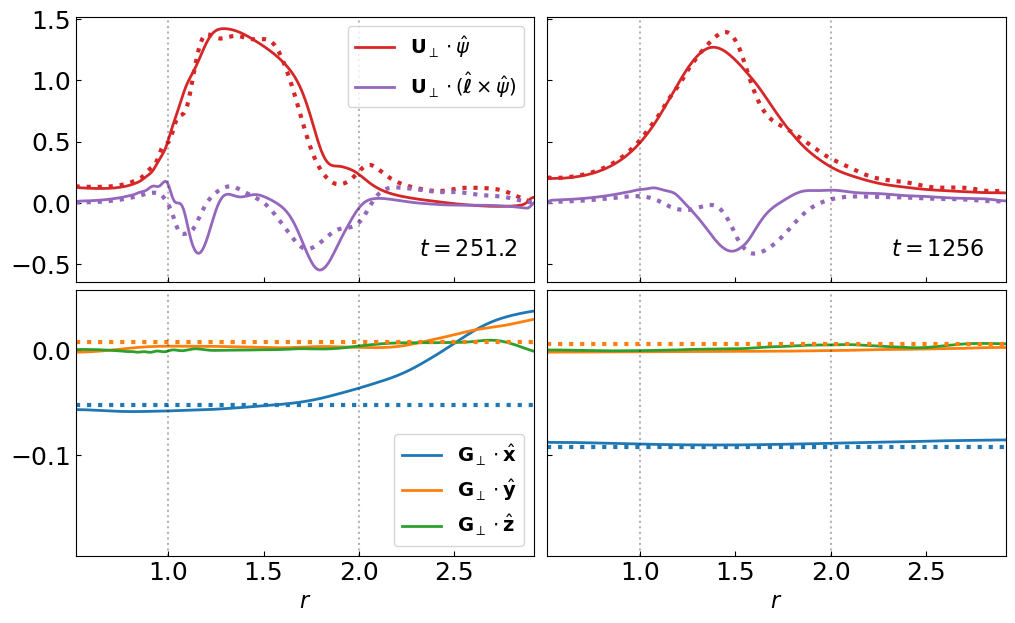

In [5]:
fig, axs = plt.subplots(2, 2, figsize=(12, 7), sharex=True, sharey="row")
fig.subplots_adjust(wspace=0.03, hspace=0.03)

snapshot_list = [
    "sim002-const-alpha-t251.200",
    "sim002-const-alpha-t1256.001",
]

alpha0 = 0.018889
i_r_a, i_r_b = 3, -10

for i, snapshot in enumerate(snapshot_list):
    diag = load_snapshot_diagnostics(snapshot)

    r = diag["r"]
    epsilon = diag["epsilon"]
    sigma = diag["sigma"]
    psi = diag["psi"]
    G_xyz = diag["G_xyz"]
    Gm = diag["Gm"]
    Gn = diag["Gn"]

    W_analytic = np.interp(r, R_plot, W_list[i])
    G_analytic = np.interp(r, R_plot, G_list[i])

    Q2 = alpha0 / (epsilon ** 2 + 4 * alpha0 ** 2) * psi
    Q3 = -epsilon / (2 * (epsilon ** 2 + 4 * alpha0 ** 2)) * psi

    sl = slice(i_r_a, i_r_b)
    psi_safe = np.where(np.abs(psi) > 0, np.abs(psi), np.nan)

    axs[0, i].plot(
        r[sl],
        (-Gm / sigma)[sl],
        lw=2,
        c="C3",
        label=r"$\mathbf{U}_{\perp}\cdot\hat{\psi}$",
    )
    axs[0, i].plot(
        r[sl],
        (-Gn / sigma)[sl],
        lw=2,
        c="C4",
        label=r"$\mathbf{U}_{\perp}\cdot(\hat{\mathbf{\ell}}\times\hat{\psi})$",
    )
    axs[0, i].plot(r[sl], 2 * Q2[sl], lw=3, c="C3", ls=":")
    axs[0, i].plot(r[sl], 2 * Q3[sl], lw=3, c="C4", ls=":")

    axs[1, i].plot(
        r[sl],
        G_xyz[0, sl],
        lw=2,
        label=r"$\mathbf{G}_{\perp}\cdot\hat{\mathbf{x}}$",
    )
    axs[1, i].plot(
        r[sl],
        G_xyz[1, sl],
        lw=2,
        label=r"$\mathbf{G}_{\perp}\cdot\hat{\mathbf{y}}$",
    )
    axs[1, i].plot(
        r[sl],
        G_xyz[2, sl],
        lw=2,
        label=r"$\mathbf{G}_{\perp}\cdot\hat{\mathbf{z}}$",
    )
    axs[1, i].plot(r[sl], np.real(G_analytic)[sl], lw=3, c="C0", ls=":")
    axs[1, i].plot(r[sl], np.imag(G_analytic)[sl], lw=3, c="C1", ls=":")

axs[0, 0].legend(frameon=True, fontsize=14, ncol=1)
axs[1, 0].legend(frameon=True, fontsize=14, ncol=1)

axs[0, 0].text(0.75, 0.1, r"$t=251.2$", transform=axs[0, 0].transAxes, fontsize=16)
axs[0, 1].text(0.75, 0.1, r"$t=1256$", transform=axs[0, 1].transAxes, fontsize=16)

axs[1, 0].set_xlabel(r"$r$", fontsize=16)
axs[1, 1].set_xlabel(r"$r$", fontsize=16)
axs[1, 0].set_xlim(diag["r"][[i_r_a, i_r_b - 1]])
axs[1, 0].set_ylim([-0.031 * 2 * np.pi, 0.009 * 2 * np.pi])

for ax in axs.flatten():
    ax.tick_params(which="both", direction="in")
    ax.axvline(x=R_gap_in, c="k", ls=":", alpha=0.3)
    ax.axvline(x=R_gap_out, c="k", ls=":", alpha=0.3)

plt.show()
